# Accuracy/Flips vs Speedup (Manual Log Selection)

Use this notebook to compare methods by **accuracy**, **flips**, and **estimated speedup**.
You manually map each method to one `run_benchmark_compare` directory.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


In [ ]:
# ---- User config ----

def find_repo_root(start: Path) -> Path:
    for cand in [start] + list(start.parents):
        if (cand / 'experiments').is_dir() and (cand / 'run' / 'main.py').is_file():
            return cand
    return start

REPO_ROOT = find_repo_root(Path.cwd())

# Benchmarks to include in the plots.
BENCHMARKS = ['gsm8k', 'human-eval-instruct']

# Manual method -> experiment log directory mapping.
# Paths are relative to REPO_ROOT.
METHOD_RUN_DIRS = {
    'int4': 'experiments/s200_int4/run_benchmark_compare',
    'kv_rewrite_128': 'experiments/s200_kvr128/run_benchmark_compare',
    'kv_rewrite_32': 'experiments/s200_kvr32/run_benchmark_compare',
    'kv_rewrite_24': 'experiments/s200_kvr24/run_benchmark_compare',
    'kv_rewrite_16': 'experiments/s200_kvr16/run_benchmark_compare',
    'lossy_sd': 'experiments/s200_sd_lossy/run_benchmark_compare',
    'lossless_sd': 'experiments/s200_sd/run_benchmark_compare',
}

# Use this method run's base_accuracy as fp16 baseline.
BASELINE_SOURCE_METHOD = 'int4'

# Plot order.
METHOD_ORDER = ['fp16', 'int4', 'kv_rewrite_16', 'kv_rewrite_24', 'kv_rewrite_32', 'kv_rewrite_128', 'lossy_sd', 'lossless_sd']

print(f'cwd: {Path.cwd()}')
print(f'repo root: {REPO_ROOT}')
print(f'benchmarks: {BENCHMARKS}')
print(f'methods: {list(METHOD_RUN_DIRS.keys())}')
if not METHOD_RUN_DIRS:
    raise ValueError('Set METHOD_RUN_DIRS first.')
if BASELINE_SOURCE_METHOD not in METHOD_RUN_DIRS:
    raise ValueError(f'BASELINE_SOURCE_METHOD must be one of {list(METHOD_RUN_DIRS.keys())}')


cwd: /home/scott306lr/coding/subspec_v2/analysis
repo root: /home/scott306lr/coding/subspec_v2
benchmarks: ['gsm8k']
methods: ['int4', 'kv_rewrite_128', 'kv_rewrite_32', 'kv_rewrite_24', 'kv_rewrite_16', 'lossy_sd', 'lossless_sd']


In [3]:
def load_json_objects(path: Path) -> list[dict]:
    text = path.read_text().strip()
    if not text:
        return []
    dec = json.JSONDecoder()
    objs = []
    i = 0
    while i < len(text):
        while i < len(text) and text[i].isspace():
            i += 1
        if i >= len(text):
            break
        obj, i = dec.raw_decode(text, i)
        objs.append(obj)
    return objs


def resolve_run_dir(raw: str) -> Path:
    p = Path(raw).expanduser()
    if not p.is_absolute():
        p = REPO_ROOT / p
    return p.resolve()


def load_method_benchmark_record(run_dir: Path, bench: str, method: str) -> dict:
    result_path = run_dir / bench / 'results.jsonl'
    if not result_path.exists():
        raise FileNotFoundError(f'Missing results.jsonl: {result_path}')

    objs = load_json_objects(result_path)
    if not objs:
        raise ValueError(f'Empty results file: {result_path}')

    # Keep last matching compare_name record for this benchmark.
    for obj in reversed(objs):
        rec = obj.get(bench)
        if isinstance(rec, dict) and rec.get('compare_name') == method:
            return rec

    raise ValueError(
        f'No record with compare_name={method!r} in {result_path}. '
        f'Found compare_name values: {[obj.get(bench, {}).get("compare_name") for obj in objs if isinstance(obj.get(bench), dict)]}'
    )


rows = []
for method, raw_run_dir in METHOD_RUN_DIRS.items():
    run_dir = resolve_run_dir(raw_run_dir)
    if not run_dir.is_dir():
        raise FileNotFoundError(f'Run dir not found for {method}: {run_dir}')

    for bench in BENCHMARKS:
        rec = load_method_benchmark_record(run_dir, bench, method)
        rows.append(
            {
                'method': method,
                'benchmark': bench,
                'run_dir': str(run_dir),
                'base_accuracy': rec.get('base_accuracy'),
                'accuracy': rec.get('compare_accuracy'),
                'flips_rate': rec.get('flips_rate'),
                'samples': rec.get('samples'),
            }
        )


if not rows:
    raise RuntimeError('No records loaded.')

df = pd.DataFrame(rows)

# Basic sanity check for missing method/benchmark combinations.
expected = {(m, b) for m in METHOD_RUN_DIRS for b in BENCHMARKS}
actual = set(zip(df['method'], df['benchmark']))
missing = sorted(expected - actual)
if missing:
    raise RuntimeError(f'Missing method/benchmark results: {missing}')

df


,method,benchmark,run_dir,base_accuracy,accuracy,flips_rate,samples
0,int4,gsm8k,/home/scott306lr/coding/subspec_v2/experiments...,0.8,0.785,0.155,200
1,kv_rewrite_128,gsm8k,/home/scott306lr/coding/subspec_v2/experiments...,0.8,0.815,0.115,200
2,kv_rewrite_32,gsm8k,/home/scott306lr/coding/subspec_v2/experiments...,0.8,0.815,0.085,200
3,kv_rewrite_24,gsm8k,/home/scott306lr/coding/subspec_v2/experiments...,0.8,0.790,0.090,200
4,kv_rewrite_16,gsm8k,/home/scott306lr/coding/subspec_v2/experiments...,0.8,0.760,0.100,200
5,lossy_sd,gsm8k,/home/scott306lr/coding/subspec_v2/experiments...,0.8,0.815,0.095,200
6,lossless_sd,gsm8k,/home/scott306lr/coding/subspec_v2/experiments...,0.8,0.795,0.005,200


In [4]:
# ---- Speed model ----
SPEED_MODEL = {
    # fp16 baseline (offload-bound)
    't_fp16_load': 1.0,
    't_fp16_target': 0.011 / 0.258,

    # int4 target fits memory
    't_int4_target': 0.007 / 0.258,

    # draft forward pass cost
    't_draft': (0.365 / 32) / 0.258,

    # accepted tokens per target verify update for SD methods
    'accepted_tokens_sd': {
        'lossless_sd': 23.78,
        'lossy_sd': 31.9,
    },
}

# KV-rewrite assumptions.
KV_TOKENS_PER_DRAFT_FORWARD = 1.0
KV_TARGET_EXTRA_TOKENS = 0.0


def weighted_avg(values: pd.Series, weights: pd.Series) -> float:
    v = values.astype(float)
    w = weights.astype(float)
    if w.sum() == 0:
        return np.nan
    return float((v * w).sum() / w.sum())


def parse_kv_depth(method: str) -> int | None:
    m = re.match(r'^kv_rewrite_(\d+)$', str(method))
    return int(m.group(1)) if m else None


def fp16_cycle_time(model: dict) -> float:
    return float(model['t_fp16_load']) + float(model['t_fp16_target'])


def overlap_speedup(accepted_tokens: float, draft_passes: float, model: dict) -> float:
    t_load = float(model['t_fp16_load'])
    t_target = float(model['t_fp16_target'])
    t_draft = float(model['t_int4_target'])
    base_cycle = fp16_cycle_time(model)
    method_cycle = max(t_load, draft_passes * t_draft) + t_target
    return float(accepted_tokens * base_cycle / method_cycle)


def sequential_speedup(accepted_tokens: float, draft_passes: float, model: dict) -> float:
    t_load = float(model['t_fp16_load'])
    t_target = float(model['t_fp16_target'])
    t_draft = float(model['t_draft'])
    base_cycle = fp16_cycle_time(model)
    method_cycle = t_load + t_target*10 + draft_passes * t_draft
    return float(accepted_tokens * base_cycle / method_cycle)


def estimate_speedup(method: str) -> float:
    base_cycle = fp16_cycle_time(SPEED_MODEL)

    if method == 'fp16':
        return 1.0
    if method == 'int4':
        return float(base_cycle / float(SPEED_MODEL['t_int4_target']))

    depth = parse_kv_depth(method)
    if depth is not None:
        accepted = float(depth * KV_TOKENS_PER_DRAFT_FORWARD + KV_TARGET_EXTRA_TOKENS)
        return overlap_speedup(accepted_tokens=accepted, draft_passes=float(depth), model=SPEED_MODEL)

    accepted_tokens_sd = SPEED_MODEL['accepted_tokens_sd']
    if method in accepted_tokens_sd:
        accepted = float(accepted_tokens_sd[method])
        # SD in this implementation version: no overlap.
        return sequential_speedup(accepted_tokens=accepted, draft_passes=accepted, model=SPEED_MODEL)

    return np.nan


summary = (
    df.groupby('method', as_index=False)
      .apply(lambda g: pd.Series({
          'accuracy': weighted_avg(g['accuracy'], g['samples']),
          'flips_rate': weighted_avg(g['flips_rate'], g['samples']),
          'samples': float(g['samples'].sum()),
      }))
      .reset_index(drop=True)
)

base_df = df[df['method'] == BASELINE_SOURCE_METHOD]
fp16_acc = weighted_avg(base_df['base_accuracy'], base_df['samples'])
summary = pd.concat(
    [
        pd.DataFrame([
            {
                'method': 'fp16',
                'accuracy': fp16_acc,
                'flips_rate': 0.0,
                'samples': float(base_df['samples'].sum()),
            }
        ]),
        summary,
    ],
    ignore_index=True,
).drop_duplicates('method', keep='last')

summary['estimated_speed_vs_fp16'] = summary['method'].apply(estimate_speedup)
summary['order'] = summary['method'].apply(lambda m: METHOD_ORDER.index(m) if m in METHOD_ORDER else 10_000)
summary = summary.sort_values(['order', 'method']).drop(columns=['order']).reset_index(drop=True)

summary


,method,accuracy,flips_rate,samples,estimated_speed_vs_fp16
0,fp16,0.800,0.000,200.0,1.000000
1,int4,0.785,0.155,200.0,38.428571
2,kv_rewrite_16,0.760,0.100,200.0,16.000000
3,kv_rewrite_24,0.790,0.090,200.0,24.000000
4,kv_rewrite_32,0.815,0.085,200.0,32.000000
5,kv_rewrite_128,0.815,0.115,200.0,37.962514
6,lossy_sd,0.815,0.095,200.0,11.725067
7,lossless_sd,0.795,0.005,200.0,10.006905


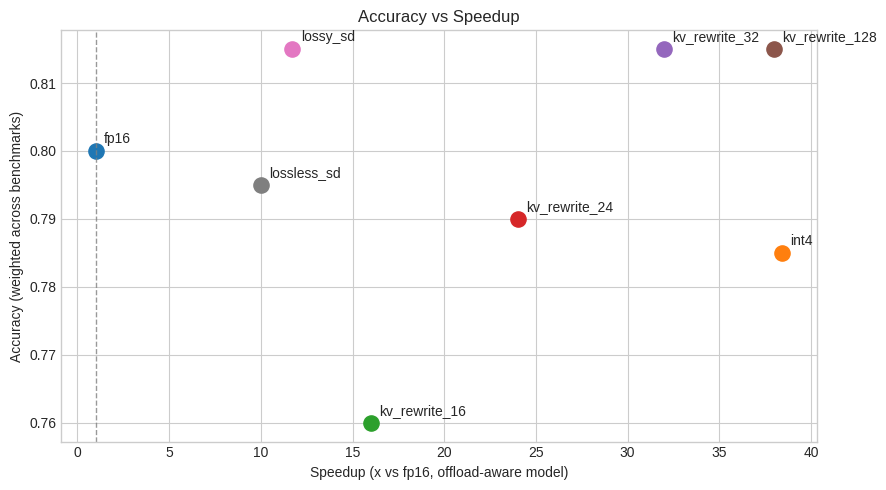

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for _, r in summary.iterrows():
    if pd.isna(r['estimated_speed_vs_fp16']):
        continue
    ax.scatter(r['estimated_speed_vs_fp16'], r['accuracy'], s=120)
    ax.annotate(r['method'], (r['estimated_speed_vs_fp16'], r['accuracy']), textcoords='offset points', xytext=(6, 6))

ax.axvline(1.0, linestyle='--', linewidth=1, color='gray', alpha=0.8)
ax.set_xlabel('Speedup (x vs fp16, offload-aware model)')
ax.set_ylabel('Accuracy (weighted across benchmarks)')
ax.set_title('Accuracy vs Speedup')
plt.tight_layout()


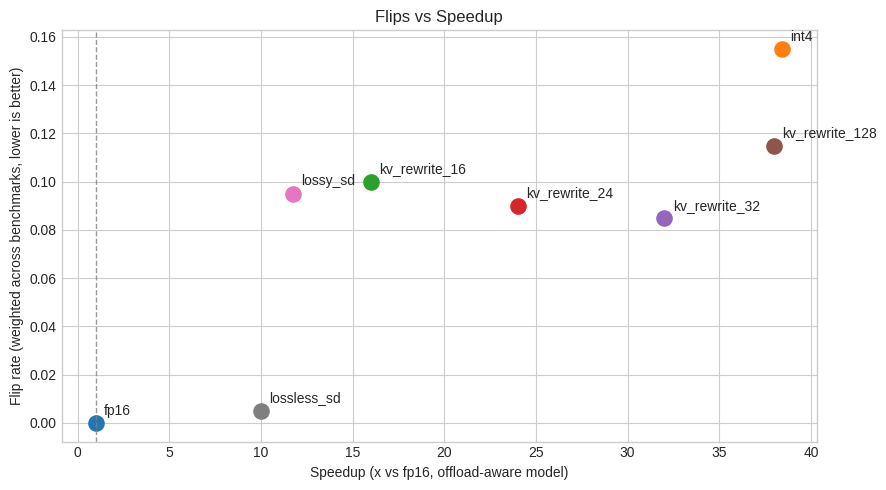

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for _, r in summary.iterrows():
    if pd.isna(r['estimated_speed_vs_fp16']):
        continue
    ax.scatter(r['estimated_speed_vs_fp16'], r['flips_rate'], s=120)
    ax.annotate(r['method'], (r['estimated_speed_vs_fp16'], r['flips_rate']), textcoords='offset points', xytext=(6, 6))

ax.axvline(1.0, linestyle='--', linewidth=1, color='gray', alpha=0.8)
ax.set_xlabel('Speedup (x vs fp16, offload-aware model)')
ax.set_ylabel('Flip rate (weighted across benchmarks, lower is better)')
ax.set_title('Flips vs Speedup')
plt.tight_layout()


## Per-benchmark views


In [7]:
speed_map = summary.set_index('method')['estimated_speed_vs_fp16'].to_dict()

per_bench = (
    df.groupby(['benchmark', 'method'], as_index=False)
      .apply(lambda g: pd.Series({
          'accuracy': weighted_avg(g['accuracy'], g['samples']),
          'flips_rate': weighted_avg(g['flips_rate'], g['samples']),
          'samples': float(g['samples'].sum()),
      }))
      .reset_index(drop=True)
)

base_rows = []
for bench in BENCHMARKS:
    g = df[(df['method'] == BASELINE_SOURCE_METHOD) & (df['benchmark'] == bench)]
    if g.empty:
        continue
    base_rows.append(
        {
            'benchmark': bench,
            'method': 'fp16',
            'accuracy': weighted_avg(g['base_accuracy'], g['samples']),
            'flips_rate': 0.0,
            'samples': float(g['samples'].sum()),
        }
    )

per_bench = pd.concat([pd.DataFrame(base_rows), per_bench], ignore_index=True)
per_bench = per_bench.drop_duplicates(subset=['benchmark', 'method'], keep='last')
per_bench['estimated_speed_vs_fp16'] = per_bench['method'].map(speed_map)
per_bench['order'] = per_bench['method'].apply(lambda m: METHOD_ORDER.index(m) if m in METHOD_ORDER else 10_000)
per_bench = per_bench.sort_values(['benchmark', 'order', 'method']).drop(columns=['order']).reset_index(drop=True)

per_bench


,benchmark,method,accuracy,flips_rate,samples,estimated_speed_vs_fp16
0,gsm8k,fp16,0.800,0.000,200.0,1.000000
1,gsm8k,int4,0.785,0.155,200.0,38.428571
2,gsm8k,kv_rewrite_16,0.760,0.100,200.0,16.000000
3,gsm8k,kv_rewrite_24,0.790,0.090,200.0,24.000000
4,gsm8k,kv_rewrite_32,0.815,0.085,200.0,32.000000
5,gsm8k,kv_rewrite_128,0.815,0.115,200.0,37.962514
6,gsm8k,lossy_sd,0.815,0.095,200.0,11.725067
7,gsm8k,lossless_sd,0.795,0.005,200.0,10.006905


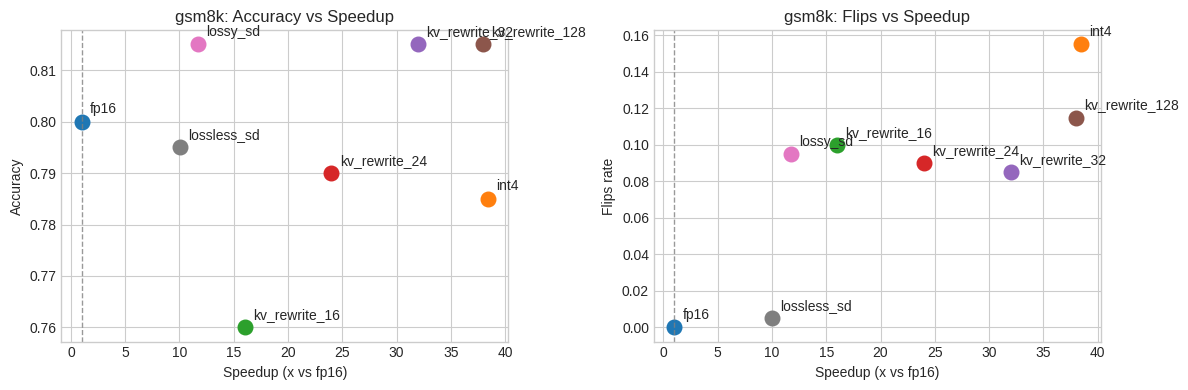

In [8]:
benchmarks = list(per_bench['benchmark'].dropna().unique())
fig, axes = plt.subplots(nrows=len(benchmarks), ncols=2, figsize=(12, 4 * len(benchmarks)), squeeze=False)

for i, bench in enumerate(benchmarks):
    bdf = per_bench[per_bench['benchmark'] == bench].copy()
    ax_acc = axes[i, 0]
    ax_flip = axes[i, 1]

    for _, r in bdf.iterrows():
        if pd.isna(r['estimated_speed_vs_fp16']):
            continue
        ax_acc.scatter(r['estimated_speed_vs_fp16'], r['accuracy'], s=110)
        ax_acc.annotate(r['method'], (r['estimated_speed_vs_fp16'], r['accuracy']), textcoords='offset points', xytext=(6, 6))

        ax_flip.scatter(r['estimated_speed_vs_fp16'], r['flips_rate'], s=110)
        ax_flip.annotate(r['method'], (r['estimated_speed_vs_fp16'], r['flips_rate']), textcoords='offset points', xytext=(6, 6))

    ax_acc.axvline(1.0, linestyle='--', linewidth=1, color='gray', alpha=0.8)
    ax_acc.set_title(f'{bench}: Accuracy vs Speedup')
    ax_acc.set_xlabel('Speedup (x vs fp16)')
    ax_acc.set_ylabel('Accuracy')

    ax_flip.axvline(1.0, linestyle='--', linewidth=1, color='gray', alpha=0.8)
    ax_flip.set_title(f'{bench}: Flips vs Speedup')
    ax_flip.set_xlabel('Speedup (x vs fp16)')
    ax_flip.set_ylabel('Flips rate')

plt.tight_layout()


## Notes
- Set `METHOD_RUN_DIRS` manually for reproducible plotting from exact experiment logs.
- `BASELINE_SOURCE_METHOD` controls which run provides fp16 baseline accuracy (`base_accuracy`).
- KV-rewrite speed uses overlap assumptions; SD speed uses no-overlap assumptions for this implementation.
